# Prediction Gaze Evaluation Viewer

This notebook compares SparseGaze-style prediction outputs against GT gaze.
It supports two levels of results:

- aggregate CSV/JSON under an eval directory, for mean/median and rate/correction summaries;
- per-sequence `sequence_predictions/*.npz`, for yaw/pitch error clouds, scanpaths, anchor effects, and event-wise diagnostics.

Update `EVAL_ROOTS` to point at the models you want to compare. The viewer does not assume a fixed model name.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from visualization.prediction_eval import (
    discover_aggregate_tables,
    discover_prediction_runs,
    load_prediction_frame,
    plot_aggregate_mae_by_hz,
    plot_anchor_error_box,
    plot_cpf_scanpath,
    plot_error_distribution,
    plot_error_timeseries,
    plot_event_error_box,
    plot_yaw_pitch_error,
    plot_yaw_pitch_trace,
    summarize_prediction_frame,
)

## Configuration

`EVAL_ROOTS` maps a display name to one model's eval directory. Add more model directories as needed.

`REPORTS_DIR` is used only to attach scene event labels. If labels are unavailable, the notebook still works but event-wise plots show `unknown`.

In [2]:
EVAL_ROOTS = {
    "rotation_only": Path("/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze_cpf_rotation_only"),
    "sparsegaze": Path("/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze"),
}
REPORTS_DIR = Path("/mnt/d/SparseGaze/ADT-Gaze-structured")

# Pick one model for the interactive section. You can change this cell and rerun below.
MODEL_NAME = "sparsegaze"
EVAL_ROOT = EVAL_ROOTS[MODEL_NAME]

## Aggregate Overview

This section uses aggregate eval CSVs. It is useful for comparing target gaze rate and correction modes, but it cannot show scanpaths or frame-level errors.

In [3]:
aggregate = discover_aggregate_tables(EVAL_ROOT)
print(f"model={MODEL_NAME}")
print(f"eval_root={EVAL_ROOT}")
print(f"aggregate rows={len(aggregate)}")

if not aggregate.empty:
    keep_cols = [
        col for col in [
            "eval_kind", "target_hz", "phase", "phase_mode", "correct_mode",
            "n_missing_total", "mae_missing_deg", "p90_missing_deg", "p95_missing_deg",
            "pred_fix_f1", "pred_sac_f1",
        ] if col in aggregate.columns
    ]
    display(aggregate[keep_cols].sort_values([c for c in ["eval_kind", "target_hz", "phase", "phase_mode", "correct_mode"] if c in keep_cols]).head(60))
else:
    print("No aggregate CSVs found.")

model=sparsegaze
eval_root=/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze
aggregate rows=30


,eval_kind,target_hz,phase,phase_mode,correct_mode,n_missing_total,mae_missing_deg,p90_missing_deg,p95_missing_deg,pred_fix_f1,pred_sac_f1
5,oracle,6,0.0,NaN,NaN,21808.0,1.395877,4.172763,6.624643,0.875711,0.546608
2,oracle,6,NaN,phase0,NaN,21808.0,1.395877,4.172763,6.624643,0.875711,0.546608
4,oracle,10,0.0,NaN,NaN,18174.0,1.394934,4.145821,6.646789,0.884560,0.542187
1,oracle,10,NaN,phase0,NaN,18174.0,1.394934,4.145821,6.646789,0.884560,0.542187
3,oracle,15,0.0,NaN,NaN,13635.0,1.400649,4.169088,6.653658,0.890786,0.393250
0,oracle,15,NaN,phase0,NaN,13635.0,1.400649,4.169088,6.653658,0.890786,0.393250
11,rollout,6,0.0,NaN,none,21808.0,3.124410,8.516012,12.474716,0.821017,0.298836
8,rollout,6,NaN,phase0,none,21808.0,3.124410,8.516012,12.474716,0.821017,0.298836
10,rollout,10,0.0,NaN,none,18174.0,2.008178,5.836908,8.785266,0.825656,0.321813
7,rollout,10,NaN,phase0,none,18174.0,2.008178,5.836908,8.785266,0.825656,0.321813


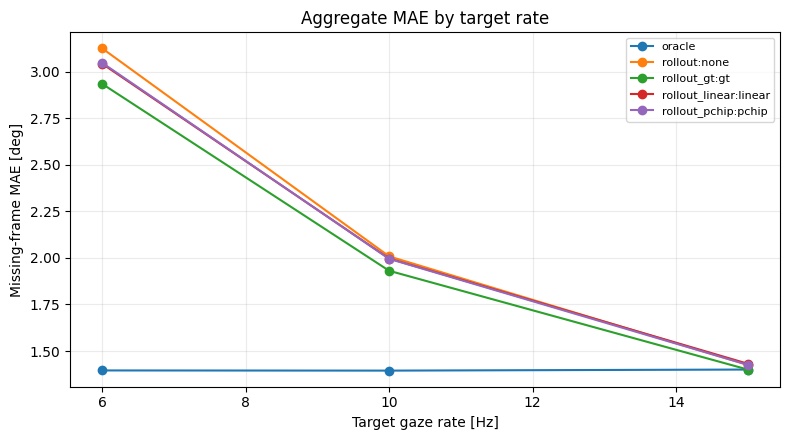

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_aggregate_mae_by_hz(aggregate, ax)
fig.tight_layout()
plt.show()

# 这个图感觉没有必要，这个错误用表格展示会很清楚的看到它们的变化；更需要绘制的是不同频率下误差随anchor distance的变化趋势。
# TODO 怎么画呢？


## Per-Sequence Prediction Selection

Detailed visualizations require `sequence_predictions/*.npz`. Choose a sequence/rate/phase/eval mode from the discovered table.

In [5]:
runs = discover_prediction_runs(EVAL_ROOT)
print(f"prediction runs={len(runs)}")
if runs.empty:
    print("No per-sequence prediction NPZ files found under this eval root.")
else:
    display(runs[["eval_kind", "sequence", "target_hz", "phase", "path"]].head(80))

prediction runs=150


,eval_kind,sequence,target_hz,phase,path
0,oracle,Apartment_release_decoration_skeleton_seq133_M...,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...
1,oracle,Apartment_release_decoration_skeleton_seq133_M...,15,0,/home/liumu/Github_Projects/SparseGaze/outputs...
2,oracle,Apartment_release_decoration_skeleton_seq133_M...,6,0,/home/liumu/Github_Projects/SparseGaze/outputs...
3,oracle,Apartment_release_decoration_skeleton_seq134_M...,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...
4,oracle,Apartment_release_decoration_skeleton_seq134_M...,15,0,/home/liumu/Github_Projects/SparseGaze/outputs...
...,...,...,...,...,...
75,rollout_gt,Apartment_release_meal_skeleton_seq135_M1292,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...
76,rollout_gt,Apartment_release_meal_skeleton_seq135_M1292,15,0,/home/liumu/Github_Projects/SparseGaze/outputs...
77,rollout_gt,Apartment_release_meal_skeleton_seq135_M1292,6,0,/home/liumu/Github_Projects/SparseGaze/outputs...
78,rollout_gt,Apartment_release_work_skeleton_seq107_M1292,10,0,/home/liumu/Github_Projects/SparseGaze/outputs...


In [6]:
# Selection defaults. Change these after inspecting `runs`.
if not runs.empty:
    SELECT_EVAL_KIND = runs["eval_kind"].iloc[0]
    SELECT_SEQUENCE = runs["sequence"].iloc[0]
    SELECT_HZ = int(runs["target_hz"].iloc[0])
    SELECT_PHASE = int(runs["phase"].iloc[0])
else:
    SELECT_EVAL_KIND = "rollout"
    SELECT_SEQUENCE = ""
    SELECT_HZ = 10
    SELECT_PHASE = 0

WINDOW_START = 0
WINDOW_END = 300

print(SELECT_EVAL_KIND, SELECT_SEQUENCE, SELECT_HZ, SELECT_PHASE)

oracle Apartment_release_decoration_skeleton_seq133_M1292 10 0


In [7]:
if runs.empty:
    pred = None
else:
    selected = runs[
        (runs["eval_kind"] == SELECT_EVAL_KIND)
        & (runs["sequence"] == SELECT_SEQUENCE)
        & (runs["target_hz"] == SELECT_HZ)
        & (runs["phase"] == SELECT_PHASE)
    ]
    if selected.empty:
        raise ValueError("No prediction file matches the current selection.")
    npz_path = Path(selected.iloc[0]["path"])
    pred = load_prediction_frame(npz_path, REPORTS_DIR)
    print(npz_path)
    display(summarize_prediction_frame(pred))

/home/liumu/Github_Projects/SparseGaze/outputs/eval/adt/sparsegaze/test/oracle/sequence_predictions/Apartment_release_decoration_skeleton_seq133_M1292/hz10_phase0.npz


,group,n,mean_angular_error_deg,median_angular_error_deg,mean_abs_yaw_error_deg,median_abs_yaw_error_deg,mean_abs_pitch_error_deg,median_abs_pitch_error_deg
0,all,1814,1.624547,0.497690,1.264968,0.337779,4.173827,0.600241
1,anchor,0,NaN,NaN,NaN,NaN,NaN,NaN
2,missing,1814,1.624547,0.497690,1.264968,0.337779,4.173827,0.600241
3,event:fixation,661,0.342757,0.289335,0.258078,0.175072,0.505483,0.361018
4,event:transition,1153,2.359381,0.919621,1.842205,0.627852,6.276841,0.969377


## Whole-Sequence Error Distribution

The left plot shows angular error magnitude. The right plot shows yaw/pitch residual direction. Orange points are missing-frame predictions, blue points are anchor frames.

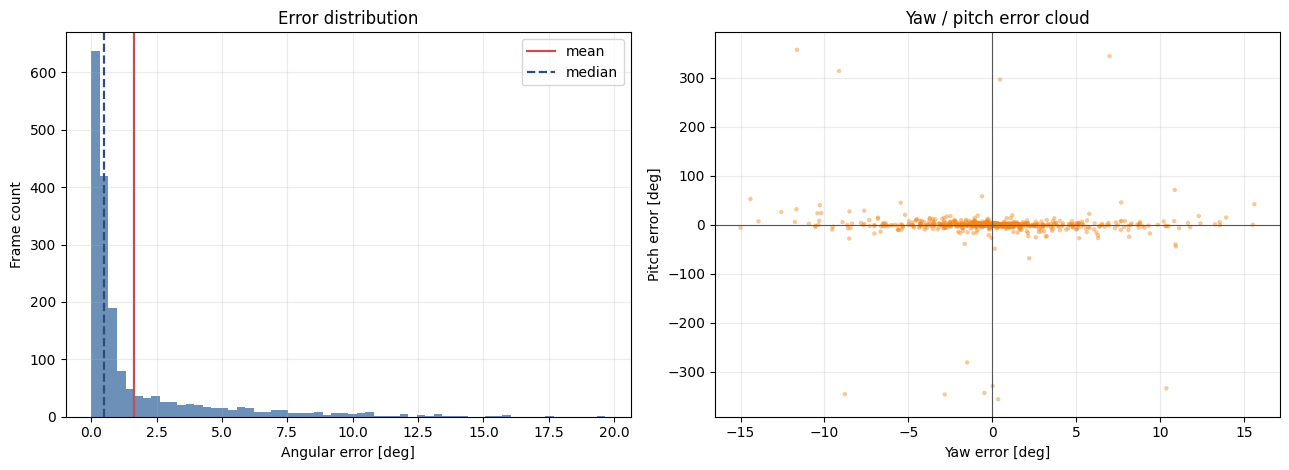

In [8]:
if pred is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    plot_error_distribution(pred, axes[0])
    plot_yaw_pitch_error(pred, axes[1])
    fig.tight_layout()
    plt.show()

## Anchor and Event Effects

These plots answer whether errors concentrate on missing frames and whether scene events explain part of the error distribution.

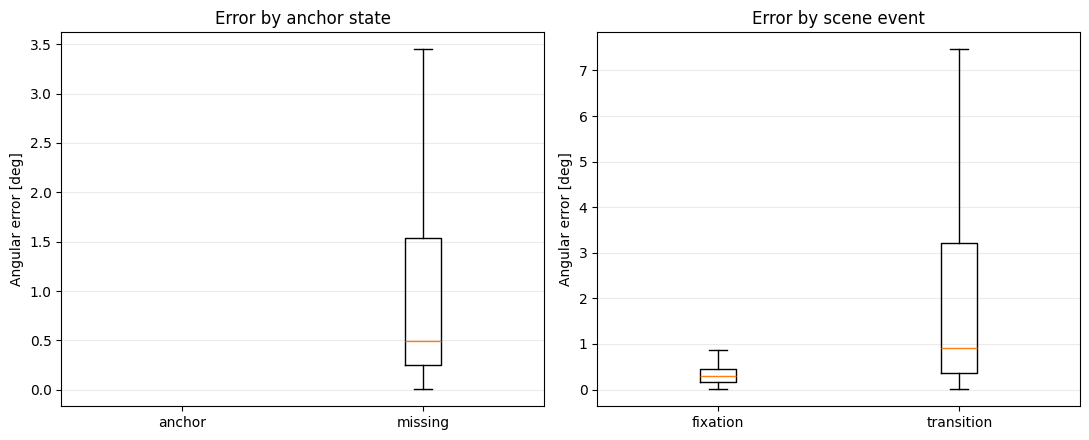

In [9]:
if pred is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    plot_anchor_error_box(pred, axes[0])
    plot_event_error_box(pred, axes[1])
    fig.tight_layout()
    plt.show()

# 这个图表示什么？

## Window-Level Diagnostics

Use this section to inspect a specific frame interval. It shows temporal error, yaw/pitch traces, and CPF yaw/pitch scanpath. Change `WINDOW_START` and `WINDOW_END` above to inspect another interval.

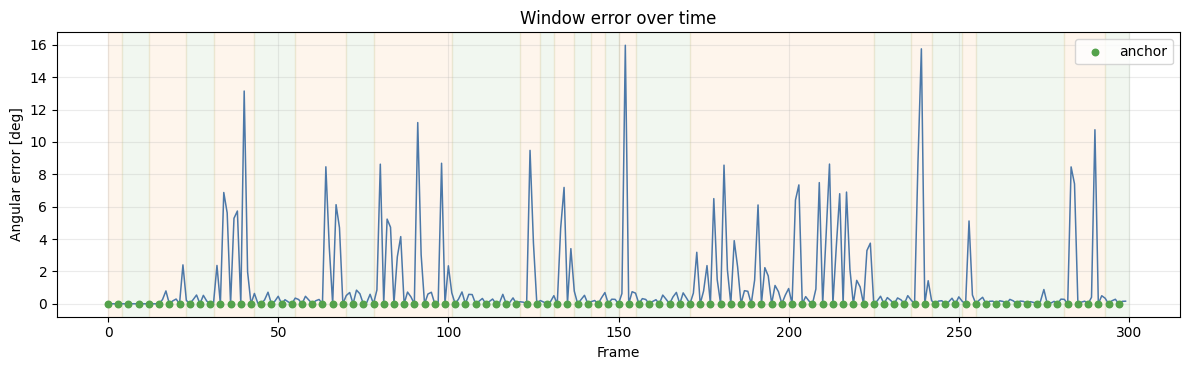

In [10]:
if pred is not None:
    fig, ax = plt.subplots(figsize=(12, 3.8))
    plot_error_timeseries(pred, ax, WINDOW_START, WINDOW_END)
    fig.tight_layout()
    plt.show()
# 这个图表示什么？

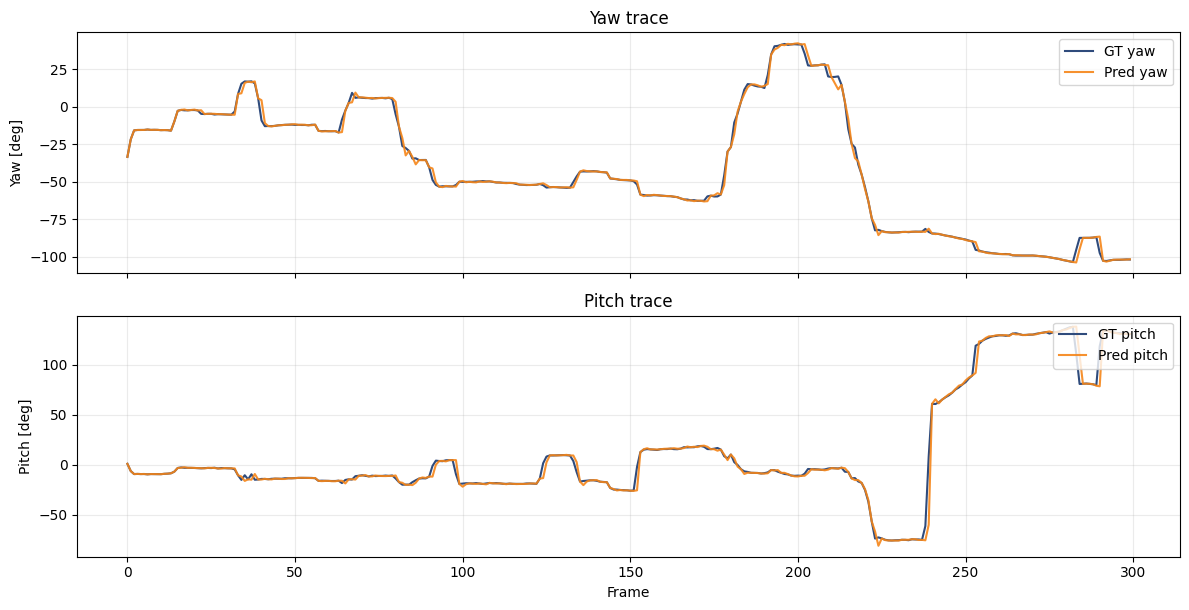

In [11]:
if pred is not None:
    fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True)
    plot_yaw_pitch_trace(pred, (axes[0], axes[1]), WINDOW_START, WINDOW_END)
    fig.tight_layout()
    plt.show()

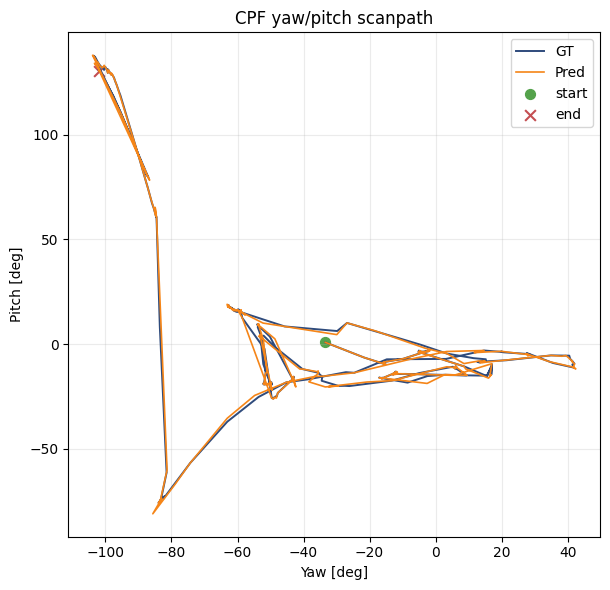

In [12]:
if pred is not None:
    fig, ax = plt.subplots(figsize=(6.2, 6.0))
    plot_cpf_scanpath(pred, ax, WINDOW_START, WINDOW_END)
    fig.tight_layout()
    plt.show()

## Notes

This first version deliberately keeps the required metrics compact:

- global mean/median error via the summary table;
- whole-sequence angular error distribution;
- yaw/pitch residual cloud for directional bias;
- anchor vs missing-frame error;
- scene-event error split;
- selected-window trace and scanpath.

Image-space and Scene-space overlays need either projected prediction points or a provider-backed projection step. Those should be added after the per-frame NPZ schema is stable across the model variants you want to compare.